# 🤖 Loan Default Prediction

### Load the dataset

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 

df = pd.read_csv("../data/loan_default_prediction_8000.csv")

print(df.head())

   Customer_ID  Age   Income  Employment_Length  Loan_Amount  Interest_Rate  \
0       100001   38  50520.0               17.0       2000.0          11.62   
1       100002   29  34003.0               30.0      24527.0          13.01   
2       100003   40  69198.0                6.0      16904.0          12.27   
3       100004   38  45669.0               14.0      26341.0          13.75   
4       100005   40  91570.0               21.0       6311.0           4.00   

   Credit_Score  Loan_Term Home_Ownership        Loan_Purpose    Education  \
0         662.0         36           Rent            Business     Bachelor   
1         834.0         60       Mortgage  Debt_Consolidation     Bachelor   
2         647.0         36            Own  Debt_Consolidation     Bachelor   
3         665.0         60       Mortgage  Debt_Consolidation     Bachelor   
4         717.0         48           Rent  Debt_Consolidation  High_School   

  Marital_Status  Default  
0         Single        0  


### Basic inspection

In [63]:
print("Shape: ", df.shape)
print()
print("Columns: ", df.columns.tolist())
print()
print("Data Types")
print(df.dtypes)

Shape:  (8000, 13)

Columns:  ['Customer_ID', 'Age', 'Income', 'Employment_Length', 'Loan_Amount', 'Interest_Rate', 'Credit_Score', 'Loan_Term', 'Home_Ownership', 'Loan_Purpose', 'Education', 'Marital_Status', 'Default']

Data Types
Customer_ID            int64
Age                    int64
Income               float64
Employment_Length    float64
Loan_Amount          float64
Interest_Rate        float64
Credit_Score         float64
Loan_Term              int64
Home_Ownership        object
Loan_Purpose          object
Education             object
Marital_Status        object
Default                int64
dtype: object


In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Customer_ID        8000 non-null   int64  
 1   Age                8000 non-null   int64  
 2   Income             7904 non-null   float64
 3   Employment_Length  7920 non-null   float64
 4   Loan_Amount        8000 non-null   float64
 5   Interest_Rate      7904 non-null   float64
 6   Credit_Score       7880 non-null   float64
 7   Loan_Term          8000 non-null   int64  
 8   Home_Ownership     7920 non-null   object 
 9   Loan_Purpose       7920 non-null   object 
 10  Education          7936 non-null   object 
 11  Marital_Status     8000 non-null   object 
 12  Default            8000 non-null   int64  
dtypes: float64(5), int64(4), object(4)
memory usage: 812.6+ KB


In [65]:
print(df.describe())

        Customer_ID          Age         Income  Employment_Length  \
count    8000.00000  8000.000000    7904.000000        7920.000000   
mean   104000.50000    43.010750   72097.099317          15.114394   
std      2309.54541    12.985673   33963.821705           8.932464   
min    100001.00000    21.000000   11077.000000           0.000000   
25%    102000.75000    32.000000   48310.500000           7.000000   
50%    104000.50000    43.000000   65514.000000          15.000000   
75%    106000.25000    54.000000   88770.500000          23.000000   
max    108000.00000    65.000000  374702.000000          30.000000   

        Loan_Amount  Interest_Rate  Credit_Score    Loan_Term      Default  
count   8000.000000    7904.000000   7880.000000  8000.000000  8000.000000  
mean   17960.992000      10.511900    691.348477    51.021000     0.324500  
std     8688.230775       3.120442     54.496180    12.473693     0.468217  
min     2000.000000       4.000000    504.000000    36.000000

In [66]:
print(df.describe(include="object"))

       Home_Ownership        Loan_Purpose Education Marital_Status
count            7920                7920      7936           8000
unique              3                   5         4              3
top              Rent  Debt_Consolidation  Bachelor        Married
freq             3827                3377      3841           3709


### Missing values

In [67]:
print(df.isnull().sum())

Customer_ID            0
Age                    0
Income                96
Employment_Length     80
Loan_Amount            0
Interest_Rate         96
Credit_Score         120
Loan_Term              0
Home_Ownership        80
Loan_Purpose          80
Education             64
Marital_Status         0
Default                0
dtype: int64


### Duplicates

In [68]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 0


### Target distribution

In [69]:
print(df["Default"].value_counts())

Default
0    5404
1    2596
Name: count, dtype: int64


In [70]:
print(df["Default"].value_counts(normalize=True))

Default
0    0.6755
1    0.3245
Name: proportion, dtype: float64


### Create a working copy

In [71]:
clean_df = df.copy()

### Target Distribution

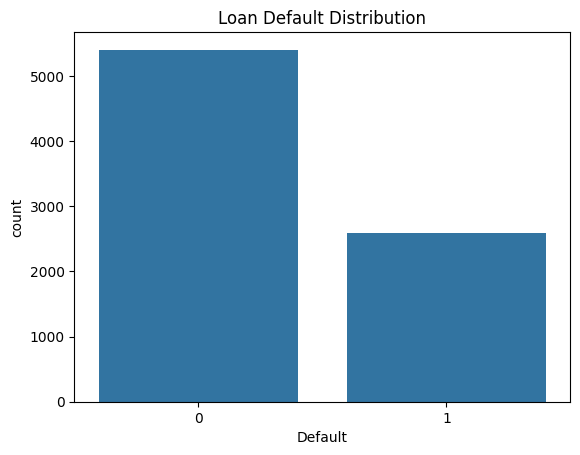

Default
0    67.55
1    32.45
Name: proportion, dtype: float64


In [72]:
sns.countplot(
    data=clean_df,
    x="Default"
)

plt.title("Loan Default Distribution")
plt.show()

print(
    clean_df["Default"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

### Numerical Feature Distributions

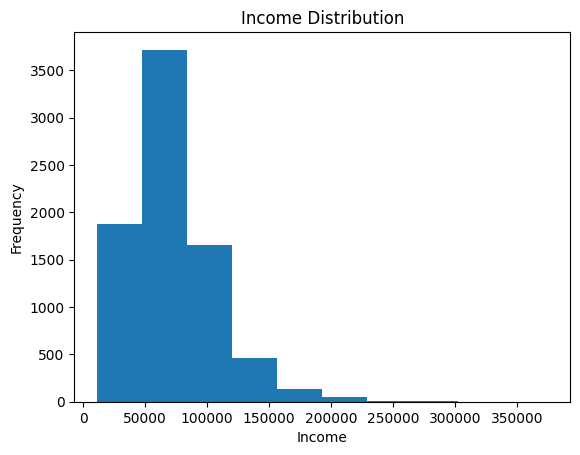

In [73]:
plt.hist(clean_df["Income"].dropna())

plt.xlabel("Income")
plt.ylabel("Frequency")
plt.title("Income Distribution")

plt.show()

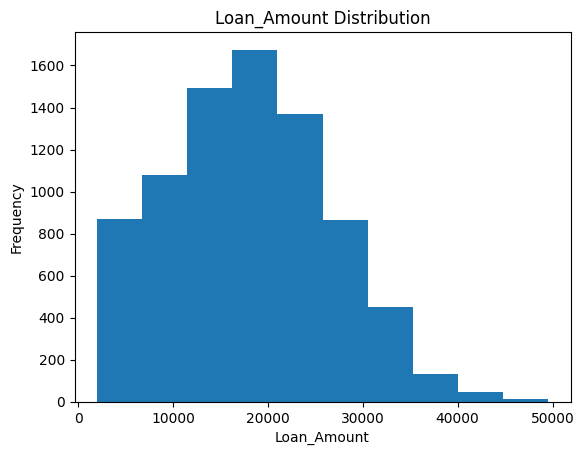

In [74]:
plt.hist(clean_df["Loan_Amount"].dropna())

plt.xlabel("Loan_Amount")
plt.ylabel("Frequency")
plt.title("Loan_Amount Distribution")

plt.show()

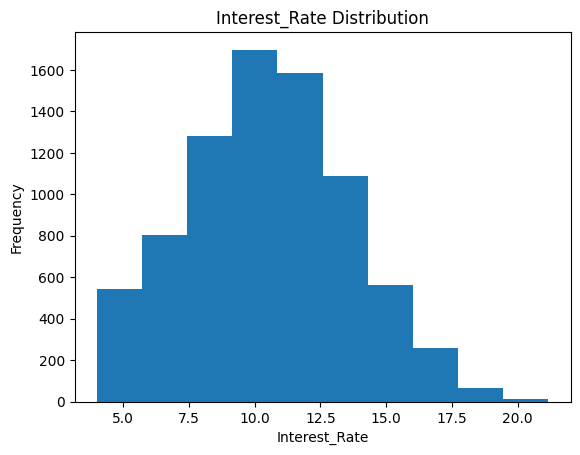

In [75]:
plt.hist(clean_df["Interest_Rate"].dropna())

plt.xlabel("Interest_Rate")
plt.ylabel("Frequency")
plt.title("Interest_Rate Distribution")

plt.show()

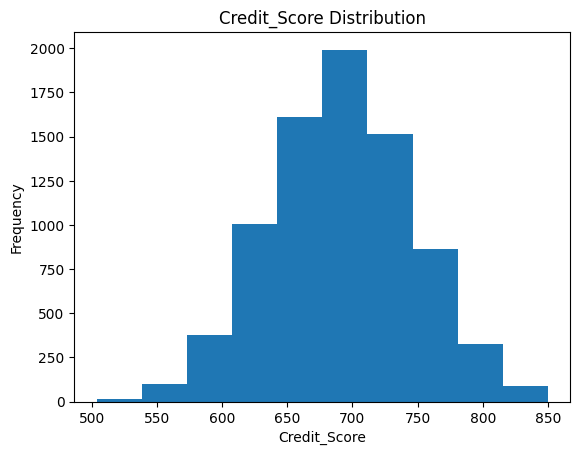

In [76]:
plt.hist(clean_df["Credit_Score"].dropna())

plt.xlabel("Credit_Score")
plt.ylabel("Frequency")
plt.title("Credit_Score Distribution")

plt.show()

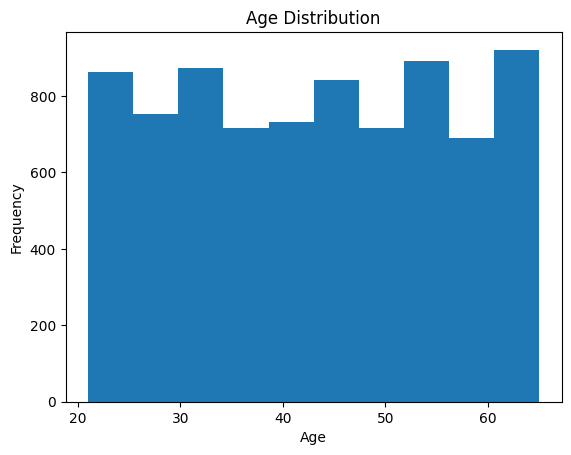

In [77]:
plt.hist(clean_df["Age"].dropna())

plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Age Distribution")

plt.show()

### Boxplots

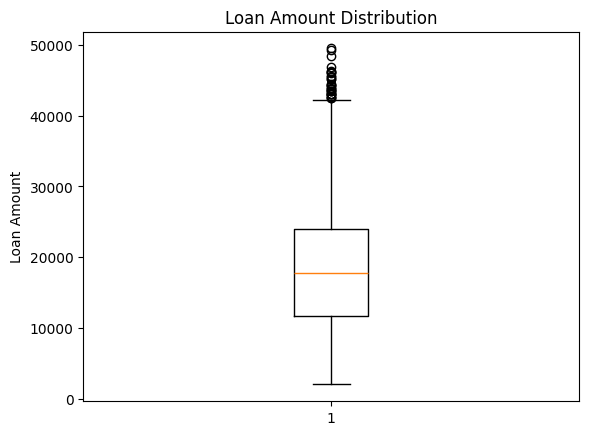

In [78]:
plt.boxplot(clean_df["Loan_Amount"].dropna())

plt.ylabel("Loan Amount")
plt.title("Loan Amount Distribution")

plt.show()

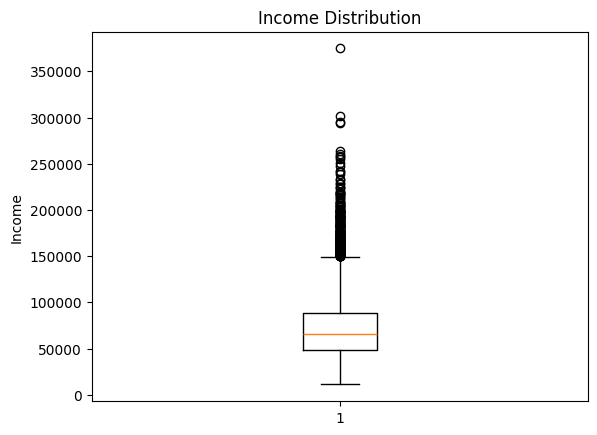

In [79]:
plt.boxplot(clean_df["Income"].dropna())

plt.ylabel("Income")
plt.title("Income Distribution")

plt.show()

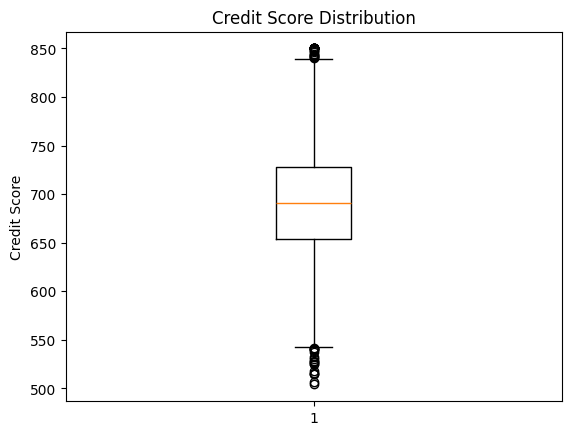

In [80]:
plt.boxplot(clean_df["Credit_Score"].dropna())

plt.ylabel("Credit Score")
plt.title("Credit Score Distribution")

plt.show()

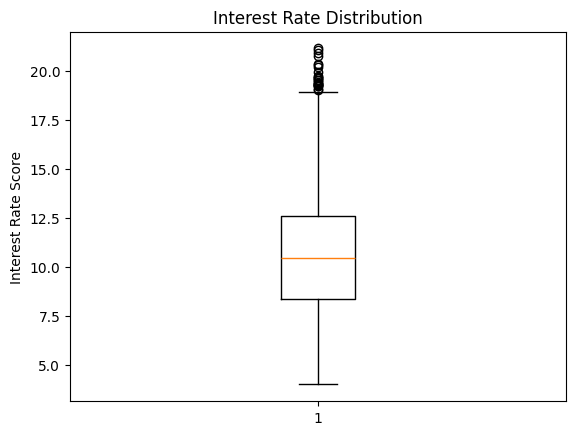

In [81]:
plt.boxplot(clean_df["Interest_Rate"].dropna())

plt.ylabel("Interest Rate Score")
plt.title("Interest Rate Distribution")

plt.show()

### Feature vs Target

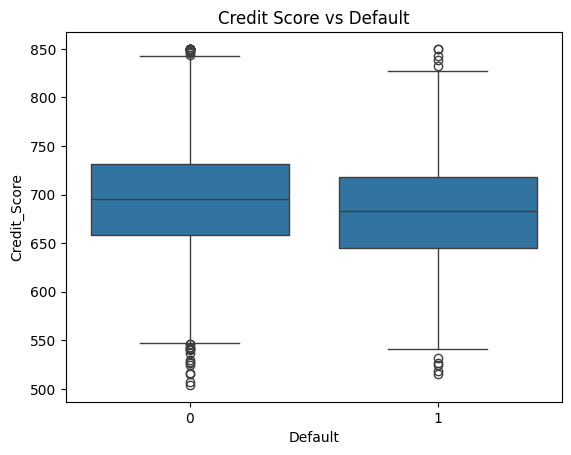

In [82]:
sns.boxplot(
    data=clean_df,
    x="Default",
    y="Credit_Score"
)

plt.title("Credit Score vs Default")
plt.show()

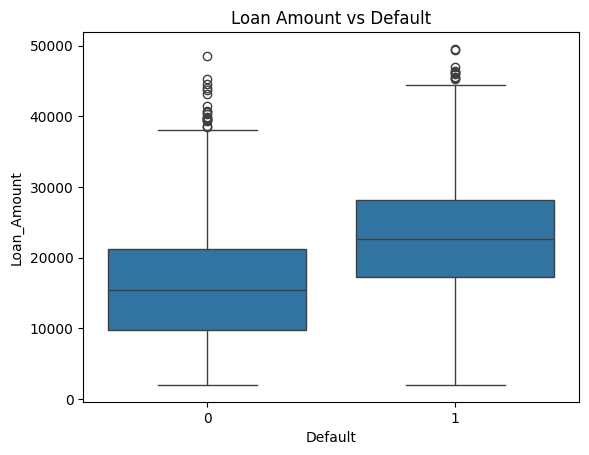

In [83]:
sns.boxplot(
    data=clean_df,
    x="Default",
    y="Loan_Amount"
)

plt.title("Loan Amount vs Default")
plt.show()

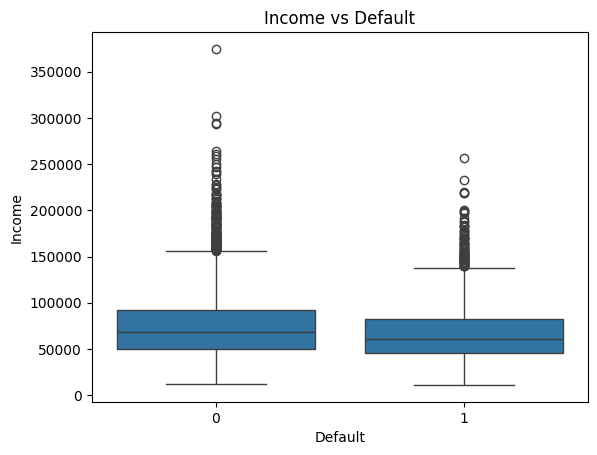

In [84]:
sns.boxplot(
    data=clean_df,
    x="Default",
    y="Income"
)

plt.title("Income vs Default")
plt.show()

### Categorical Features vs Default

In [85]:
default_by_home = clean_df.groupby(
    "Home_Ownership",
    dropna=False
)["Default"].mean()

print(
    default_by_home.sort_values(
        ascending=False
    )
)

Home_Ownership
NaN         0.375000
Rent        0.347269
Own         0.302752
Mortgage    0.302031
Name: Default, dtype: float64


In [86]:
default_by_purpose = clean_df.groupby(
    "Loan_Purpose",
    dropna=False
)["Default"].mean()

print(
    default_by_purpose.sort_values(
        ascending=False
    )
)

Loan_Purpose
NaN                   0.425000
Business              0.377593
Education             0.337500
Medical               0.327796
Debt_Consolidation    0.309742
Home_Improvement      0.308680
Name: Default, dtype: float64


In [87]:
default_by_education = clean_df.groupby(
    "Education",
    dropna=False
)["Default"].mean()

print(
    default_by_education.sort_values(
        ascending=False
    )
)

Education
High_School    0.343005
PhD            0.335648
Master         0.319677
Bachelor       0.316845
NaN            0.281250
Name: Default, dtype: float64


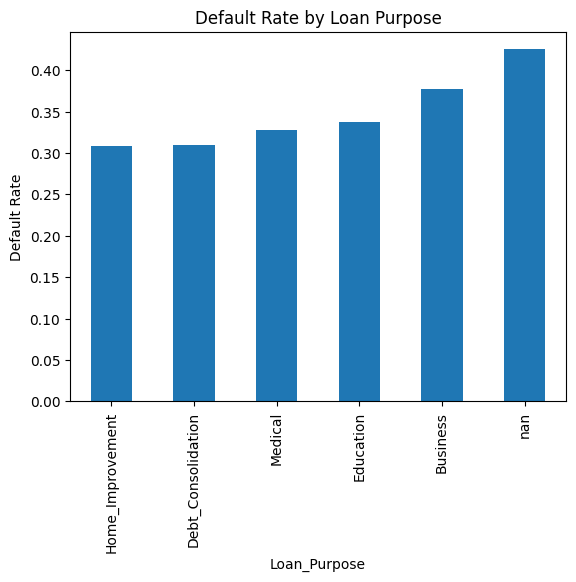

In [88]:
default_by_purpose.sort_values().plot(
    kind="bar"
)

plt.ylabel("Default Rate")
plt.title("Default Rate by Loan Purpose")
plt.show()

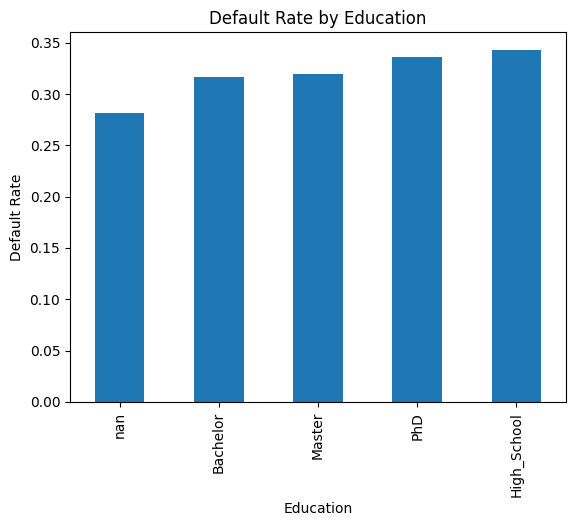

In [89]:
default_by_education.sort_values().plot(
    kind="bar"
)

plt.ylabel("Default Rate")
plt.title("Default Rate by Education")
plt.show()

### Correlation

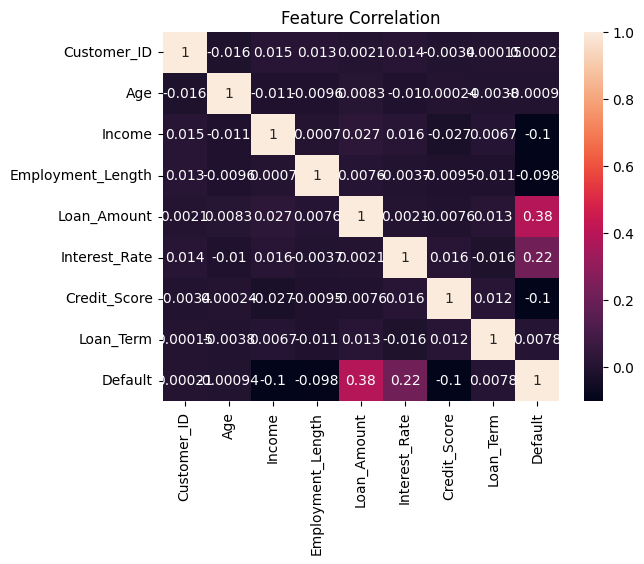

In [90]:
correlation = clean_df.corr(
    numeric_only=True
)

sns.heatmap(
    correlation,
    annot=True
)

plt.title("Feature Correlation")
plt.show()

In [91]:
default_summary = pd.DataFrame({
    "Default_Count": clean_df["Default"].value_counts(),
    "Default_Rate": clean_df["Default"].value_counts(
        normalize=True
    )
})

print(default_summary)

         Default_Count  Default_Rate
Default                             
0                 5404        0.6755
1                 2596        0.3245


### Create a working feature dataset

In [92]:
model_df = clean_df.copy()

In [93]:
model_df["Loan_to_Income"] = (
    model_df["Loan_Amount"] / model_df["Income"]
)

In [94]:
print((model_df["Income"] <= 0).sum())

0


In [95]:
model_df["Loan_Per_Month"] = (
    model_df["Loan_Amount"] / model_df["Loan_Term"]
)

In [96]:
print(
    model_df[
        [
            "Loan_Amount",
            "Income",
            "Loan_to_Income",
            "Loan_Per_Month"
        ]
    ].head()
)

   Loan_Amount   Income  Loan_to_Income  Loan_Per_Month
0       2000.0  50520.0        0.039588       55.555556
1      24527.0  34003.0        0.721319      408.783333
2      16904.0  69198.0        0.244285      469.555556
3      26341.0  45669.0        0.576781      439.016667
4       6311.0  91570.0        0.068920      131.479167


In [97]:
print(
    model_df[
        [
            "Loan_to_Income",
            "Loan_Per_Month"
        ]
    ].describe()
)

       Loan_to_Income  Loan_Per_Month
count     7904.000000     8000.000000
mean         0.303279      374.623808
std          0.215253      209.319621
min          0.009208       27.777778
25%          0.155472      225.243056
50%          0.256116      346.933333
75%          0.398693      496.856250
max          2.047914     1304.500000


### Remove the Identifier from ML Features

In [98]:
X = model_df.drop(
    columns=["Customer_ID", "Default"]
)

y = model_df["Default"]

In [99]:
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nX columns:")
print(X.columns.tolist())

print("\ny distribution:")
print(y.value_counts())

X shape: (8000, 13)
y shape: (8000,)

X columns:
['Age', 'Income', 'Employment_Length', 'Loan_Amount', 'Interest_Rate', 'Credit_Score', 'Loan_Term', 'Home_Ownership', 'Loan_Purpose', 'Education', 'Marital_Status', 'Loan_to_Income', 'Loan_Per_Month']

y distribution:
Default
0    5404
1    2596
Name: count, dtype: int64


### Identify Numerical Features & Categorical Features

In [100]:
numeric_features = [
    "Age",
    "Income",
    "Employment_Length",
    "Loan_Amount",
    "Interest_Rate",
    "Credit_Score",
    "Loan_Term",
    "Loan_to_Income",
    "Loan_Per_Month"
]

categorical_features = [
    "Home_Ownership",
    "Loan_Purpose",
    "Education",
    "Marital_Status"
]

### Train/Test Split

In [101]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [102]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

X_train: (6400, 13)
X_test: (1600, 13)
y_train: (6400,)
y_test: (1600,)

Training target distribution:
Default
0    0.675469
1    0.324531
Name: proportion, dtype: float64

Testing target distribution:
Default
0    0.675625
1    0.324375
Name: proportion, dtype: float64


### Numerical Pipeline & Categorical Pipeline

In [103]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer", 
            SimpleImputer(strategy="median")
        ),
        (
            "scaler", StandardScaler()
        )
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer", 
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder", 
            OneHotEncoder(handle_unknown="ignore")
        )
    ]
)

### Combine Them

In [104]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_pipeline,
            numeric_features
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_features
        )
    ]
)

In [105]:
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

print("Train shape:", X_train_transformed.shape)
print("Test shape:", X_test_transformed.shape)

print(
    preprocessor.get_feature_names_out()
)

Train shape: (6400, 24)
Test shape: (1600, 24)
['num__Age' 'num__Income' 'num__Employment_Length' 'num__Loan_Amount'
 'num__Interest_Rate' 'num__Credit_Score' 'num__Loan_Term'
 'num__Loan_to_Income' 'num__Loan_Per_Month'
 'cat__Home_Ownership_Mortgage' 'cat__Home_Ownership_Own'
 'cat__Home_Ownership_Rent' 'cat__Loan_Purpose_Business'
 'cat__Loan_Purpose_Debt_Consolidation' 'cat__Loan_Purpose_Education'
 'cat__Loan_Purpose_Home_Improvement' 'cat__Loan_Purpose_Medical'
 'cat__Education_Bachelor' 'cat__Education_High_School'
 'cat__Education_Master' 'cat__Education_PhD'
 'cat__Marital_Status_Divorced' 'cat__Marital_Status_Married'
 'cat__Marital_Status_Single']


In [106]:
print(
    np.isnan(
        X_train_transformed
    ).sum()
)

0


### Create the Models

In [107]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import (
    GradientBoostingClassifier,
    RandomForestClassifier
)

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "SVM": SVC(
        kernel="rbf",
        probability=True
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    )
}

In [108]:
pipelines = {}

for name, model in models.items():

    pipelines[name] = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "model",
                model
            )
        ]
    )

In [109]:
for name, pipeline in pipelines.items():
    print(name)
    print(pipeline)
    print()

Logistic Regression
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Income',
                                                   'Employment_Length',
                                                   'Loan_Amount',
                                                   'Interest_Rate',
                                                   'Credit_Score', 'Loan_Term',
                                                   'Loan_to_Income',
                                                   'Loan_Per_Month']),
                                                 ('

In [110]:
print(models.keys())

dict_keys(['Logistic Regression', 'KNN', 'SVM', 'Decision Tree', 'Random Forest', 'Gradient Boosting'])


### Train every model

In [111]:
for name, pipeline in pipelines.items():

    pipeline.fit(
        X_train,
        y_train
    )

    print(name, "Trained")

Logistic Regression Trained
KNN Trained


SVM Trained
Decision Tree Trained
Random Forest Trained
Gradient Boosting Trained


### Optional verification

In [112]:
print(pipelines.keys())

dict_keys(['Logistic Regression', 'KNN', 'SVM', 'Decision Tree', 'Random Forest', 'Gradient Boosting'])


In [113]:
for name, pipeline in pipelines.items():
    print(
        name,
        "→",
        type(pipeline.named_steps["model"]).__name__
    )

Logistic Regression → LogisticRegression
KNN → KNeighborsClassifier
SVM → SVC
Decision Tree → DecisionTreeClassifier
Random Forest → RandomForestClassifier
Gradient Boosting → GradientBoostingClassifier


### Generate predictions for all six

In [114]:
predictions = {}

for name, pipeline in pipelines.items():
    predictions[name] = pipeline.predict(X_test)

for name, prediction in predictions.items():
    print(name)
    print(prediction[0:10])
    print()

Logistic Regression
[0 0 0 1 0 0 1 0 1 0]

KNN
[0 0 0 1 0 0 1 0 1 0]

SVM
[0 0 0 1 0 0 1 0 1 0]

Decision Tree
[0 0 0 1 0 0 1 0 1 0]

Random Forest
[0 0 0 1 0 0 1 0 1 0]

Gradient Boosting
[0 0 0 1 0 0 1 0 1 0]



### Evaluate all six together

In [115]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

evaluation_results = []

for name, prediction in predictions.items():

    evaluation_results.append({
        "Model": name,
        "Accuracy": accuracy_score(
            y_test,
            prediction
        ),
        "Precision": precision_score(
            y_test,
            prediction,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            prediction,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            prediction,
            zero_division=0
        )
    })

evaluation_df = pd.DataFrame(evaluation_results)

print(
    evaluation_df.sort_values(
        "F1",
        ascending=False
    )
)

                 Model  Accuracy  Precision    Recall        F1
0  Logistic Regression  0.761875   0.686486  0.489403  0.571429
5    Gradient Boosting  0.757500   0.681440  0.473988  0.559091
3        Decision Tree  0.745000   0.645669  0.473988  0.546667
4        Random Forest  0.750625   0.676471  0.443160  0.535506
2                  SVM  0.760000   0.721311  0.423892  0.533981
1                  KNN  0.707500   0.564885  0.427746  0.486842


### Cross-validation for all six

In [116]:
from sklearn.model_selection import cross_val_score

cv_results = []

for name, pipeline in pipelines.items():

    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=5,
        scoring="f1"
    )

    cv_results.append({
        "Model": name,
        "Mean_CV_F1": scores.mean(),
        "STD_CV_F1": scores.std()
    })

cv_df = pd.DataFrame(cv_results)

print(
    cv_df.sort_values(
        "Mean_CV_F1",
        ascending=False
    )
)

                 Model  Mean_CV_F1  STD_CV_F1
0  Logistic Regression    0.567682   0.014108
5    Gradient Boosting    0.557961   0.015142
4        Random Forest    0.540325   0.017138
3        Decision Tree    0.525567   0.035690
2                  SVM    0.518134   0.014105
1                  KNN    0.487811   0.011396


### One final comparison table

In [117]:
final_comparison = evaluation_df.merge(
    cv_df,
    on="Model"
)

final_comparison = final_comparison.sort_values(
    "Mean_CV_F1",
    ascending=False
)

print(final_comparison.round(3))

                 Model  Accuracy  Precision  Recall     F1  Mean_CV_F1  \
0  Logistic Regression     0.762      0.686   0.489  0.571       0.568   
5    Gradient Boosting     0.758      0.681   0.474  0.559       0.558   
4        Random Forest     0.751      0.676   0.443  0.536       0.540   
3        Decision Tree     0.745      0.646   0.474  0.547       0.526   
2                  SVM     0.760      0.721   0.424  0.534       0.518   
1                  KNN     0.708      0.565   0.428  0.487       0.488   

   STD_CV_F1  
0      0.014  
5      0.015  
4      0.017  
3      0.036  
2      0.014  
1      0.011  


### Add Train F1

In [118]:
train_result = []

for name, pipeline in pipelines.items():

    train_prediction = pipeline.predict(X_train)

    train_result.append({
        "Model": name,
        "Train_F1": f1_score(
            y_train,
            train_prediction,
            zero_division=0
        )
    })

train_df = pd.DataFrame(train_result)

final_comparison = final_comparison.merge(
    train_df,
    on="Model"
)

In [119]:
final_comparison = final_comparison[
    [
        "Model",
        "Train_F1",
        "F1",
        "Mean_CV_F1",
        "STD_CV_F1",
        "Accuracy",
        "Precision",
        "Recall"
    ]
]

print(
    final_comparison.round(3)
)

                 Model  Train_F1     F1  Mean_CV_F1  STD_CV_F1  Accuracy  \
0  Logistic Regression     0.572  0.571       0.568      0.014     0.762   
1    Gradient Boosting     0.621  0.559       0.558      0.015     0.758   
2        Random Forest     1.000  0.536       0.540      0.017     0.751   
3        Decision Tree     0.571  0.547       0.526      0.036     0.745   
4                  SVM     0.586  0.534       0.518      0.014     0.760   
5                  KNN     0.658  0.487       0.488      0.011     0.708   

   Precision  Recall  
0      0.686   0.489  
1      0.681   0.474  
2      0.676   0.443  
3      0.646   0.474  
4      0.721   0.424  
5      0.565   0.428  


### Improving Logistic Regression

In [120]:
logistic_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LogisticRegression(
                max_iter=1000
            )
        )
    ]
)

### GridSearchCV for Logistic Regression

In [128]:
param_grid = {
    "model__C": [
        0.01,
        0.1,
        1,
        10,
        100
    ]
}

from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

In [129]:
grid_search.fit(
    X_train,
    y_train
)

,estimator,Pipeline(step..._iter=1000))])
,param_grid,"{'model__C': [0.01, 0.1, ...]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [130]:
print("Best Parameters:")
print(grid_search.best_params_)

print("Best CV F1:")
print(grid_search.best_score_)

Best Parameters:
{'model__C': 1}
Best CV F1:
0.5676820116820741


In [132]:
best_logistic = grid_search.best_estimator_

test_prediction = best_logistic.predict(X_test)

print(
    "Accuracy:",
    accuracy_score(
        y_test,
        test_prediction
    )
)

print(
    "Precision:",
    precision_score(
        y_test,
        test_prediction,
        zero_division=0
    )
)

print(
    "Recall:",
    recall_score(
        y_test,
        test_prediction,
        zero_division=0
    )
)

print(
    "F1:",
    f1_score(
        y_test,
        test_prediction,
        zero_division=0
    )
)

Accuracy: 0.761875
Precision: 0.6864864864864865
Recall: 0.48940269749518306
F1: 0.5714285714285714


In [133]:
logistic_results = pd.DataFrame(
    grid_search.cv_results_
)

print(
    logistic_results[
        [
            "param_model__C",
            "mean_test_score",
            "std_test_score",
            "rank_test_score"
        ]
    ].sort_values(
        "rank_test_score"
    )
)

   param_model__C  mean_test_score  std_test_score  rank_test_score
2            1.00         0.567682        0.014108                1
3           10.00         0.566976        0.014100                2
4          100.00         0.566976        0.014100                2
1            0.10         0.565639        0.013154                4
0            0.01         0.553569        0.009708                5


### Random Forest Tuning with GridSearchCV

In [134]:
rf_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            RandomForestClassifier(
                random_state=42
            )
        )
    ]
)

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [3, 5, 10],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

In [135]:
rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

rf_grid.fit(
    X_train,
    y_train
)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__max_depth': [3, 5, ...], 'model__min_samples_leaf': [1, 2], 'model__min_samples_split': [2, 5], 'model__n_estimators': [100, 200]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [136]:
print("Best Parameters:")
print(rf_grid.best_params_)

print("Best CV F1:")
print(rf_grid.best_score_)

Best Parameters:
{'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 200}
Best CV F1:
0.5369922805539993


In [137]:
best_rf = rf_grid.best_estimator_

rf_test_prediction = best_rf.predict(X_test)

print(
    "Accuracy:",
    accuracy_score(
        y_test,
        rf_test_prediction
    )
)

print(
    "Precision:",
    precision_score(
        y_test,
        rf_test_prediction,
        zero_division=0
    )
)

print(
    "Recall:",
    recall_score(
        y_test,
        rf_test_prediction,
        zero_division=0
    )
)

print(
    "F1:",
    f1_score(
        y_test,
        rf_test_prediction,
        zero_division=0
    )
)

Accuracy: 0.755
Precision: 0.6978193146417445
Recall: 0.43159922928709055
F1: 0.5333333333333333


In [138]:
rf_train_prediction = best_rf.predict(X_train)

rf_train_f1 = f1_score(
    y_train,
    rf_train_prediction,
    zero_division=0
)

rf_test_f1 = f1_score(
    y_test,
    rf_test_prediction,
    zero_division=0
)

print("Train F1:", rf_train_f1)
print("Test F1:", rf_test_f1)

Train F1: 0.740423098913665
Test F1: 0.5333333333333333


In [139]:
rf_results = pd.DataFrame(
    rf_grid.cv_results_
)

print(
    rf_results[
        [
            "param_model__n_estimators",
            "param_model__max_depth",
            "param_model__min_samples_split",
            "param_model__min_samples_leaf",
            "mean_test_score",
            "std_test_score",
            "rank_test_score"
        ]
    ]
    .sort_values("rank_test_score")
    .head(10)
)

    param_model__n_estimators  param_model__max_depth  \
19                        200                      10   
18                        100                      10   
17                        200                      10   
22                        100                      10   
16                        100                      10   
23                        200                      10   
21                        200                      10   
20                        100                      10   
12                        100                       5   
14                        100                       5   

    param_model__min_samples_split  param_model__min_samples_leaf  \
19                               5                              1   
18                               5                              1   
17                               2                              1   
22                               5                              2   
16                         

### Gradient Boosting Tuning with GridSearchCV

In [140]:
gb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            GradientBoostingClassifier(
                random_state=42
            )
        )
    ]
)

param_grid = {
    "model__n_estimators": [50, 100, 200],
    "model__learning_rate": [0.03, 0.1],
    "model__max_depth": [1, 2, 3]
}

gb_grid = GridSearchCV(
    estimator=gb_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

gb_grid.fit(
    X_train,
    y_train
)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__learning_rate': [0.03, 0.1], 'model__max_depth': [1, 2, ...], 'model__n_estimators': [50, 100, ...]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [141]:
print("Best Parameters:")
print(gb_grid.best_params_)

print("Best CV F1:")
print(gb_grid.best_score_)

Best Parameters:
{'model__learning_rate': 0.1, 'model__max_depth': 2, 'model__n_estimators': 200}
Best CV F1:
0.5659151080231194


In [142]:
best_gb = gb_grid.best_estimator_

gb_test_prediction = best_gb.predict(X_test)

print(
    "Accuracy:",
    accuracy_score(
        y_test,
        gb_test_prediction
    )
)

print(
    "Precision:",
    precision_score(
        y_test,
        gb_test_prediction,
        zero_division=0
    )
)

print(
    "Recall:",
    recall_score(
        y_test,
        gb_test_prediction,
        zero_division=0
    )
)

print(
    "F1:",
    f1_score(
        y_test,
        gb_test_prediction,
        zero_division=0
    )
)

Accuracy: 0.75625
Precision: 0.6816901408450704
Recall: 0.4662813102119461
F1: 0.5537757437070938


In [143]:
gb_train_prediction = best_gb.predict(X_train)

gb_train_f1 = f1_score(
    y_train,
    gb_train_prediction,
    zero_division=0
)

gb_test_f1 = f1_score(
    y_test,
    gb_test_prediction,
    zero_division=0
)

print("Train F1:", gb_train_f1)
print("Test F1:", gb_test_f1)

Train F1: 0.6078376092472512
Test F1: 0.5537757437070938


In [144]:
gb_results = pd.DataFrame(
    gb_grid.cv_results_
)

print(
    gb_results[
        [
            "param_model__n_estimators",
            "param_model__learning_rate",
            "param_model__max_depth",
            "mean_test_score",
            "std_test_score",
            "rank_test_score"
        ]
    ]
    .sort_values("rank_test_score")
    .head(10)
)

    param_model__n_estimators  param_model__learning_rate  \
14                        200                        0.10   
13                        100                        0.10   
16                        100                        0.10   
11                        200                        0.10   
8                         200                        0.03   
17                        200                        0.10   
15                         50                        0.10   
5                         200                        0.03   
12                         50                        0.10   
7                         100                        0.03   

    param_model__max_depth  mean_test_score  std_test_score  rank_test_score  
14                       2         0.565915        0.011010                1  
13                       2         0.560990        0.016199                2  
16                       3         0.557961        0.015142                3  
11          